# Week 5 Day 5 – Bivariate Analysis

## Objective

Study the relationship between Reliance Industries and the Nifty 50 Index.

Tasks:

- Download Reliance and Nifty 50 data
- Calculate daily returns
- Compute rolling 60-day correlation
- Visualize how correlation changes over time
- Identify periods of decoupling

In [17]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

## Download Data

Using yfinance to fetch:

- RELIANCE.NS
- ^NSEI (Nifty 50)

In [18]:
tickers = [
    "RELIANCE.NS",
    "^NSEI"
]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

data.head()

[*********************100%***********************]  2 of 2 completed


Price            Close                      High                       Low  \
Ticker     RELIANCE.NS         ^NSEI RELIANCE.NS         ^NSEI RELIANCE.NS   
Date                                                                         
2020-01-01  672.216187  12182.500000  680.008852  12222.200195  670.390532   
2020-01-02  683.660278  12282.200195  686.176208  12289.900391  673.284921   
2020-01-03  684.484070  12226.650391  686.487896  12265.599609  678.183128   
2020-01-06  668.609314  11993.049805  680.365044  12179.099609  667.050769   
2020-01-07  678.895630  12052.950195  683.304036  12152.150391  673.952826   

Price                           Open                    Volume            
Ticker             ^NSEI RELIANCE.NS         ^NSEI RELIANCE.NS     ^NSEI  
Date                                                                      
2020-01-01  12165.299805  675.956671  12202.150391    14004468  304100.0  
2020-01-02  12195.250000  673.284921  12198.549805    17710316  407700.0  
2020-01-03  12191.349609  682.636062  12261.099609    20984698  428800.0  
2020-01-06  11974.200195  676.847260  12170.599609    24519177  396500.0  
2020-01-07  12005.349609  676.401934  12079.099609    16683622  447800.0

In [19]:
close = data["Close"]

close.head()

Ticker,RELIANCE.NS,^NSEI
Date,,
2020-01-01,672.216187,12182.500000
2020-01-02,683.660278,12282.200195
2020-01-03,684.484070,12226.650391
2020-01-06,668.609314,11993.049805
2020-01-07,678.895630,12052.950195


## Daily Returns

Compute percentage daily returns.

In [20]:
# returns = close.pct_change().dropna()
returns = close.pct_change(fill_method=None).dropna()

returns.head()

Ticker,RELIANCE.NS,^NSEI
Date,,
2020-01-02,0.017024,0.008184
2020-01-03,0.001205,-0.004523
2020-01-06,-0.023192,-0.019106
2020-01-07,0.015385,0.004995
2020-01-08,-0.007510,-0.002290


## Rolling 60-Day Correlation

Measures how strongly Reliance and Nifty moved together over the previous 60 trading days.

In [21]:
rolling_corr = (
    returns["RELIANCE.NS"]
    .rolling(60)
    .corr(
        returns["^NSEI"]
    )
)

rolling_corr.head()

Date
2020-01-02   NaN
2020-01-03   NaN
2020-01-06   NaN
2020-01-07   NaN
2020-01-08   NaN
dtype: float64

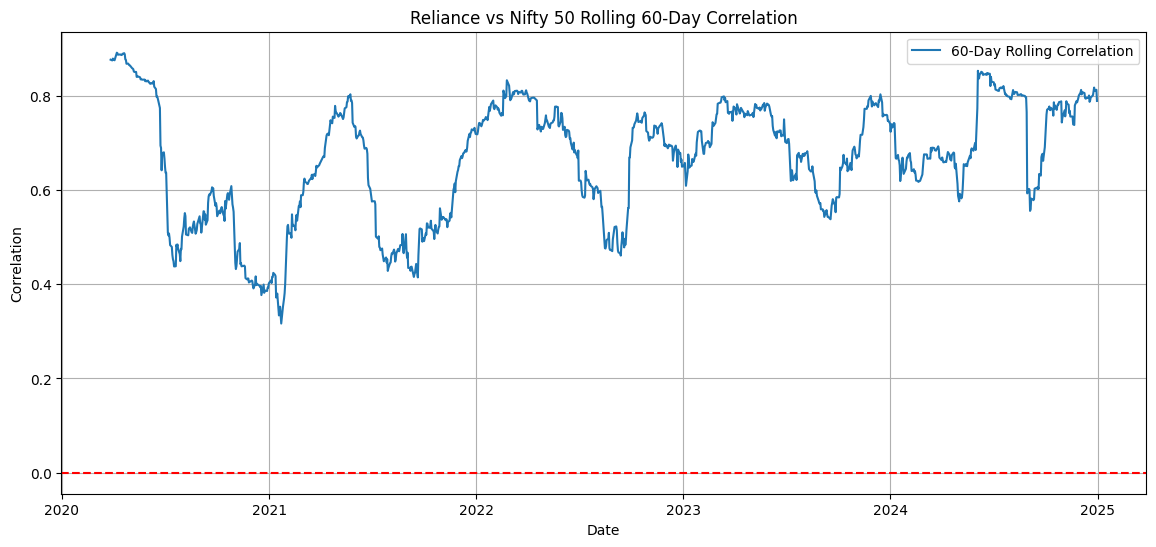

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    rolling_corr.index,
    rolling_corr,
    label="60-Day Rolling Correlation"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title(
    "Reliance vs Nifty 50 Rolling 60-Day Correlation"
)

plt.xlabel("Date")
plt.ylabel("Correlation")

plt.grid(True)
plt.legend()

plt.savefig(
    "../images/rolling_correlation.png",
  
  dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
rolling_corr.nsmallest(10)

Date
2021-01-22    0.316488
2021-01-21    0.333184
2021-01-18    0.333732
2021-01-19    0.349238
2021-01-25    0.351487
2021-01-20    0.352245
2021-01-27    0.369635
2021-01-13    0.371693
2021-01-14    0.374608
2020-12-18    0.376870
dtype: float64

## Interpretation

The rolling 60-day correlation between Reliance and the Nifty 50 remained positive for most of the study period, indicating that Reliance generally moved in line with the broader market.

However, several periods showed a noticeable decline in correlation. These decoupling periods suggest that company-specific events or sector-specific factors influenced Reliance more strongly than overall market movements.

Overall, Reliance exhibited a strong but time-varying relationship with the Nifty 50 index.